## Reading Cleaned Data

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score , mean_squared_error,mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
PATH = "Dataset/cleaned_data.csv"

In [3]:
df = pd.read_csv(PATH)
df.head()

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,...,attendance_percentage,stress_level,focus_score,final_grade,productivity_score,total_distraction_hours,study_efficiency,balance_score,caffeine_sleep_ratio,engagement_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,...,57.21,10,57,81.87,33.78,13.20,0.459770,5.480000,74.946004,114.42
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,...,91.27,10,49,60.90,48.99,11.85,1.628664,7.046667,53.166227,912.70
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,...,63.14,2,38,86.22,36.60,13.35,1.606426,4.960000,98.356808,505.12
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,...,40.51,6,50,71.77,19.87,22.28,5.642633,5.046667,31.899642,729.18
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,...,45.53,6,41,90.13,52.90,15.72,0.912647,7.960000,60.471567,318.71


In [4]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day', 'sleep_hours',
       'phone_usage_hours', 'social_media_hours', 'youtube_hours',
       'gaming_hours', 'breaks_per_day', 'coffee_intake_mg',
       'exercise_minutes', 'assignments_completed', 'attendance_percentage',
       'stress_level', 'focus_score', 'final_grade', 'productivity_score',
       'total_distraction_hours', 'study_efficiency', 'balance_score',
       'caffeine_sleep_ratio', 'engagement_score'],
      dtype='str')

In [5]:
features = [
    'study_hours_per_day',
    'sleep_hours',
    'balance_score',
    'study_efficiency',
    'phone_usage_hours',
    'total_distraction_hours',
    'attendance_percentage',
    'caffeine_sleep_ratio'
]

In [6]:
X = df[features]
y = df['productivity_score']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", round(r2_score(y_test, y_pred), 4))

R2 Score: 0.786


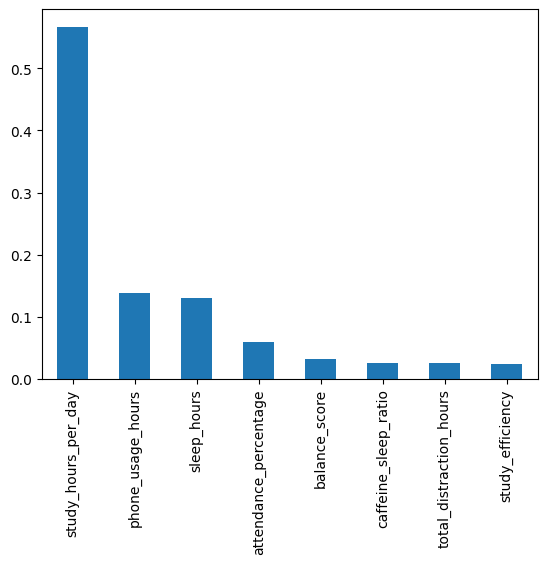

In [9]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

importance.plot(kind='bar')
plt.show()

In [10]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.ensemble import RandomForestRegressor

param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': [None, 10, 15],
    'min_samples_split': randint(2, 8),
    'min_samples_leaf': randint(1, 4)
}

rf = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=15,        # Only 15 random tries
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'min_samples_leaf': <scipy.stats....0013B4F8C33E0>, 'min_samples_split': <scipy.stats....0013B4F973620>, 'n_estimators': <scipy.stats....0013B4F6F3EF0>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscro

In [11]:
print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

best_model = random_search.best_estimator_

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 3, 'n_estimators': 291}
Best CV Score: 0.780483406532328


In [14]:
y_pred = best_model.predict(X_test)

print("Test R2:", round(r2_score(y_test, y_pred), 4))
print("MAE:", round(mean_absolute_error(y_test, y_pred), 4))
print("RMSE:", round(np.sqrt(((y_pred - y_test)**2).mean()), 4))

Test R2: 0.7895
MAE: 6.1829
RMSE: 7.4278


In [16]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [18]:
import joblib

# Save model
joblib.dump(best_model, "productivity_model.pkl")

print("Model saved successfully!")

Model saved successfully!
